# IMT 573 - Final Examination


Points: 100

Name: Kathleen Ashbaker

### Instructions

This is a take-home final examination. You may use your computer, books/articles, notes, course materials, etc., but all work must be your own! Please review the course policy on AI-based learning tools. References must be appropriately cited. Please justify your answers and show all work; a complete argument must be presented to obtain full credit. Before beginning this exam, please ensure you have access to data programming environments used in the course; this can be on your own personal computer or on shared infrastructure hosted by the university. 

1. Download the exam template notebook file from Canvas. Open exam notebook and supply your solutions to the exam by editing the notebook. 

2. Be sure the exam contains your full name. 

3. Be sure to include well-documented (e.g. commented) code chucks, figures, and clearly written text chunk explanations as necessary. Any figures should be clearly labeled and appropriately referenced within the text. Be sure that each visualization adds value to your written explanation; avoid redundancy -- you do not need four different visualizations of the same pattern.

4.  **Collaboration is not allowed on this exam. You may only speak with the course instructor about this material.**

5. All materials and resources that you use (with the exception of lecture slides) must be appropriately referenced within your assignment.

6. Remember partial credit will be awarded for each question for which a serious attempt at finding an answer has been shown. Students are **strongly** encouraged to attempt each question and to document their reasoning process even if they cannot find the correct answer. If you would like to include code to show this process, but it does not run without errors, you can do so by commenting out that code. 

7. When you have completed the assignment and have **checked** that your code both runs in the Console and compiles correctly rename the file to `YourLastName_YourFirstName.ipynb`, and submit BOTH your HTML and notebook files on Canvas.

### Statement of Compliance

You **must** include the a "signed" Statement of Compliance in your submission. The Compliance Statement is found below. You must include this text, word-for-word, in your final exam submission. Adding your name indicates you have read the statement and agree to its terms. Failure to do so will result in your exam **not** being accepted.

**Statement of Compliance**

I affirm that I have had no conversation regarding this exam with any persons other than the instructor. Further, I certify that the attached work represents my own thinking. Any information, concepts, or words that originate from other sources are cited in accordance with University of Washington guidelines as published in the Academic Code (available on the course website). I am aware of the serious consequences that result from improper discussions with others or from the improper citation of work that is not my own. 

Kathleen Ashbaker 

11-30-2025




For this assignment, you'll need (at least) the following packages. If the package does not load, be sure it is properly installed.

In [224]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

### Problem 1

Points: 20

In this problem we will use data on infidelity, known as the Fair's Affairs dataset. The `Affairs` dataset is available as part of the `datasets` package in`statsmodels`. This data comes from a survey conducted by Psychology Today in 1969, see Greene (2003) and Fair (1978) for more information. 

The dataset contains various self-reported characteristics of 6366 participants, including how often the respondent engaged in extramarital sexual intercourse during the past year, as well as their gender, age, year married, whether they had children, their religiousness (on a 5-point scale, from 1=anti to 5=very), education, occupation (Hillingshead 7-point classification with reverse numbering), and a numeric self-rating of their marriage (from 1=very unhappy to 5=very happy).

(a) Describe the participants. Use descriptive, summarization, and exploratory techniques to describe the participants in the study. Tell us the average/mean of children count ? What is the average age of respondents? In your response comment on any ethical and privacy concerns you have with this dataset. 

In [225]:
affairs = sm.datasets.fair.load_pandas().data
print(sm.datasets.fair.NOTE)

::

    Number of observations: 6366
    Number of variables: 9
    Variable name definitions:

        rate_marriage   : How rate marriage, 1 = very poor, 2 = poor, 3 = fair,
                        4 = good, 5 = very good
        age             : Age
        yrs_married     : No. years married. Interval approximations. See
                        original paper for detailed explanation.
        children        : No. children
        religious       : How relgious, 1 = not, 2 = mildly, 3 = fairly,
                        4 = strongly
        educ            : Level of education, 9 = grade school, 12 = high
                        school, 14 = some college, 16 = college graduate,
                        17 = some graduate school, 20 = advanced degree
        occupation      : 1 = student, 2 = farming, agriculture; semi-skilled,
                        or unskilled worker; 3 = white-colloar; 4 = teacher
                        counselor social worker, nurse; artist, writers;
          

This dataset describes 6,366 observations with 9 variables which include how they rate their marriage on a scale of 1 to 5 with 1 being "very poor" to 5 being "very good", age, years married, presence or absense of children, religious preferences educational attainment, occupation, husband's occupation, and  time spent having an affair. 

In [226]:
affairs.head() 

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


In [227]:


summary = affairs.describe()

avg_children_count =affairs ['children'].mean()

avg_age_respondent = affairs ['age'].mean()

summary, avg_children_count, avg_age_respondent # shows the average number of children and the average age of the respondents. 

(       rate_marriage          age  yrs_married     children    religious  \
 count    6366.000000  6366.000000  6366.000000  6366.000000  6366.000000   
 mean        4.109645    29.082862     9.009425     1.396874     2.426170   
 std         0.961430     6.847882     7.280120     1.433471     0.878369   
 min         1.000000    17.500000     0.500000     0.000000     1.000000   
 25%         4.000000    22.000000     2.500000     0.000000     2.000000   
 50%         4.000000    27.000000     6.000000     1.000000     2.000000   
 75%         5.000000    32.000000    16.500000     2.000000     3.000000   
 max         5.000000    42.000000    23.000000     5.500000     4.000000   
 
               educ   occupation  occupation_husb      affairs  
 count  6366.000000  6366.000000      6366.000000  6366.000000  
 mean     14.209865     3.424128         3.850141     0.705374  
 std       2.178003     0.942399         1.346435     2.203374  
 min       9.000000     1.000000         1.00

The average count of children is 1.39. 
The average age of the respondent is 29.08 years 

There are several ethical and privacy concerns here. One is the very nature of this information about people is considered sensitive, and age is one good  example of this. 

There is the issue of unauthorized access into the personal and private lives of individuals. Many people would prefer this information about themselves to remain private and confidential. This is especially true when the information about any children they have. 

Unauthorized release of private information such as this could also impact someone's professional reputation at work. 

(b) Suppose we want to explore the characteristics of participants who engage in extramarital sexual intercourse (i.e. affairs). Instead of modeling the number of affairs, consider the binary outcome - had an affair versus didn't have an affair. Create a new variable to capture this response variable of interest. What might the advantages and disadvantages of this approach to modeling the data be in this context?

In [228]:
affairs['had_affair']= (affairs['affairs'] > 0).astype(int)

affairs[['affairs','had_affair']].head() # check step 

,affairs,had_affair
0,0.111111,1
1,3.230769,1
2,1.400000,1
3,0.727273,1
4,4.666666,1


Advantages of binary variable modeling, in this case, whether an affair was pose as a simple yes or no answer to the question. This is appropriate for logistic models which deal with discrete binary outcomes and can pave the way for analyses such as such as odds ratios. Lastly, this information is easy to communicate to a wide variety of both technical and non-technical audiences. 

A caveat to vinary variable modeling  is that there is not much grey area in interpreting these results from a reductionist approach such as bivariate anayles. Another major disadvantage is that this approach could potentially leads to models which are overly simplified and may not explain the underlying reasons or nuances as to why affairs are had and for how long, and whether having an affair is a one time occurence vs a habitual pattern in a relationship. This may be followed up with inferential studies about the covariates and how they influence the outcome of having an affair vs not having an affair. 



(c) Use an appropriate regression model to explore the relationship between having an affair (binary) and other personal characteristics. Comment on which covariates seem to be predictive of having an affair and which do not.

In [229]:
# Covariates and Predictors 
X = affairs [['rate_marriage', 'age', 'yrs_married', 'children','religious','educ', 'occupation','occupation_husb']]

# Intercept 
X= sm.add_constant(X)

# Outcome of having an affair (binary)

Y= affairs['had_affair']

# Logistic regression modeling 

logit_model = sm.Logit (Y, X).fit()

print(logit_model.summary())


Optimization terminated successfully.
         Current function value: 0.545314
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             had_affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6357
Method:                           MLE   Df Model:                            8
Date:                Sun, 30 Nov 2025   Pseudo R-squ.:                  0.1327
Time:                        22:38:06   Log-Likelihood:                -3471.5
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                5.807e-224
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               3.7257      0.299     12.470      0.000       3.140       4.311
rate_marriage 

According to this analysis, the covariates which are statistically significant predictors of having an affair are 'rate_marriage'(martial satisfaction), 'age', 'yrs_married', 'religious', 'occupation and 'educ'( although educational attainment is a slighly less significant  predictor compared to the others). All of these covariates have p values of less than 0.05. 

(d) Use a model selection procedure to obtain a "best" fit model. Is the model different from the full model you fit in part (c)? Which variables are included in the "best" fit model? [Hint: stepwise selection] 

In [230]:
def forward_back_step_selection (X, Y, step_sel_list=[],threshold_in=0.05, threshold_out=0.10): # forward backward step selection while loop based on the p-values
    included = list(step_sel_list)

    while True: 
        changed = False 

        exclude= list((set(X.columns))-set(included)) # forward step here 
        new_p_values = pd.Series( dtype=float)
        for new_column in exclude: 
            mod = sm.Logit( Y, sm.add_constant(pd.DataFrame(X[included + [new_column ]]))). fit(disp=0)
            new_p_values.loc[new_column] = mod.pvalues[new_column]

        if not new_p_values.empty:
            best_p_value= new_p_values.min()
            if best_p_value < threshold_in:
                bestie_feature= new_p_values.idxmin()
                included.append(bestie_feature)
                changed =True         
        mod = sm.Logit( Y, sm.add_constant(pd.DataFrame(X[included]))).fit(disp=0) # back step here 
        pvals= mod.pvalues.iloc[1:]
        worst_p_val = pvals.max()
        if worst_p_val > threshold_out:
            worst_feature = pvals.idxmax()
            included.remove(worst_feature)
            changed =True 
        if not changed: 
            break 
        

    return included 

Stepwise Documentation Reference: 

Geeks For Geeks (2025, July 23). Stepwise Regression in Python. Retrieved November 25, 2025, from https://www.geeksforgeeks.org/machine-learning/stepwise-regression-in-python/

In [231]:
# run the forward and back step 

X = affairs [['rate_marriage', 'age','yrs_married', 'children', 'religious', 'educ', 'occupation','occupation_husb']]

Y = affairs [['had_affair']]



bestie_feature= forward_back_step_selection (X, Y)
bestie_feature 

['rate_marriage', 'yrs_married', 'religious', 'age', 'occupation', 'educ']

According to this stepwise selection model (both forward and back), the covariates which were identified as contributing the most statisically significant power in influencing the outcome variable of having an affair were ' rate_marriage', 'yrs_married', 'religious', 'age', 'occupation' and 'educ.' These are the predictors which are part of the best fit model. 

(e) Interpret the model parameters using the model from part (d).

Both the logistical regression and the subsequent stepwise selection reveal that martial satisfaction, number of years spent married, educational attainment, age, and  occupation( not the husband's) are statistically significant predictors of having an affair. 

Generally, positive coefficients make the event more likely and negative coefficients make the event less likely; for categorical predictors( occupation, religion, education ), positive coefficients indicate that the event is more likely at that level of the predictor than at the reference level of the factor. Negative coefficients indicate that the event is less likely at that level of the predictor than at the reference level. <sup>1</sup>

Reference: 
1. Coefficients and regression equation for fit binary logistic model and binary logistic regression. Minitab. (n.d.). https://support.minitab.com/en-us/minitab/help-and-how-to/statistical-modeling/regression/how-to/fit-binary-logistic-model/interpret-the-results/all-statistics-and-graphs/coefficients-and-regression-equation/#:~:text=Generally%2C%20positive%20coefficients%20make%20the,different%20types%20of%20predictors%20follows. 

(f) Create an artificial test dataset where martial rating varies from 1 to 5 randomly and all other variables are set to their means. Use this artificial dataset as your test dataset to obtain predicted probabilities of having an affair for case in the test data. Interpret your results and use a visualization to support your interpretation.

In [232]:
from sklearn.linear_model import LogisticRegression
X = affairs.drop(columns=["had_affair"])
Y = affairs["had_affair"]
for col in ["occupation","occupation_husb"]: # categorical conversion 
    X[col] = X[col].astype("category")
X_encode = pd.get_dummies(X, drop_first=True) # refit 
mod_new = LogisticRegression(max_iter=500).fit(X_encode, Y)
meanie_new = X.mean(numeric_only=True) # creation of new data set starts here beyond this point
testing_data_frame= pd.DataFrame({
    "rate_marriage": [1,2,3,4,5],
    **{col: meanie_new[col] for col in meanie_new.index if col !="rate_marriage"}
})
test_encode = pd.get_dummies(testing_data_frame, drop_first=True)
test_encode = test_encode.reindex(columns=X_encode.columns, fill_value=0)
testing_data_frame["pred_prob_affair"]= mod_new.predict_proba(test_encode)[:,1] # prediction of probabilities starts beyond this point 
print(testing_data_frame[["rate_marriage","pred_prob_affair"]])

   rate_marriage  pred_prob_affair
0              1          0.999988
1              2          0.999981
2              3          0.999971
3              4          0.999954
4              5          0.999928


/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: over

In [272]:
display(testing_data_frame)

,rate_marriage,age,yrs_married,children,religious,educ,affairs,pred_prob_affair
0,1,29.082862,9.009425,1.396874,2.42617,14.209865,0.705374,0.999988
1,2,29.082862,9.009425,1.396874,2.42617,14.209865,0.705374,0.999981
2,3,29.082862,9.009425,1.396874,2.42617,14.209865,0.705374,0.999971
3,4,29.082862,9.009425,1.396874,2.42617,14.209865,0.705374,0.999954
4,5,29.082862,9.009425,1.396874,2.42617,14.209865,0.705374,0.999928


In [233]:
testing_data_frame.head() # sanity check for the new data frame 

,rate_marriage,age,yrs_married,children,religious,educ,affairs,pred_prob_affair
0,1,29.082862,9.009425,1.396874,2.42617,14.209865,0.705374,0.999988
1,2,29.082862,9.009425,1.396874,2.42617,14.209865,0.705374,0.999981
2,3,29.082862,9.009425,1.396874,2.42617,14.209865,0.705374,0.999971
3,4,29.082862,9.009425,1.396874,2.42617,14.209865,0.705374,0.999954
4,5,29.082862,9.009425,1.396874,2.42617,14.209865,0.705374,0.999928


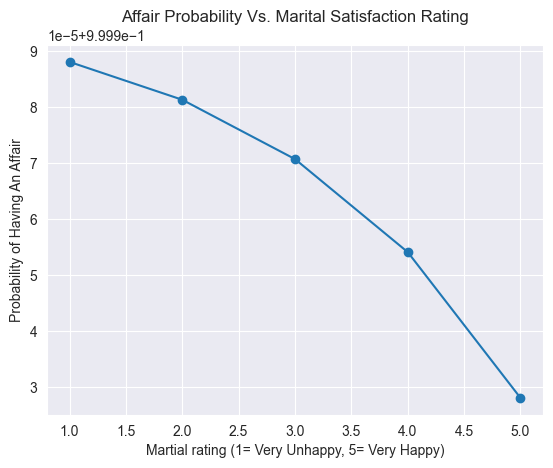

In [234]:
# Visualization Code 
plt.plot(
    testing_data_frame["rate_marriage"],
    testing_data_frame["pred_prob_affair"],
    marker="o"
)

plt.xlabel("Martial rating (1= Very Unhappy, 5= Very Happy)")
plt.ylabel("Probability of Having An Affair")
plt.title("Affair Probability Vs. Marital Satisfaction Rating")
#plt.ylim(0.95,1.0)
plt.grid(True)
plt.show()

Disclaimer: The y axis probabilities are shown in scientific notation. 

(g) Reflect on your analysis in this problem. After completing all the parts of this analysis what remaining and additional ethical and privacy conerns do you have?

One additional ethical and privacy concern I may have, one that was not mentioned previously is how this data could be used in the future, because this data is personal. There would have to be informed consent and robust de-identification measures in place to protect people's behavioral data patterns. 

### Problem 2

Points: 20

In this problem set, we will use some data from a sports context. The data is provided as part of the [Introduction to Statistial Learning with Applications in Python](https://www.statlearning.com/) textbook. It was taken from the StatLib library which is maintained at Carnegie Mellon University. The data provided is part of the data that was used in the 1988 ASA Graphics Section Poster Session. The salary data were originally from Sports Illustrated, April 20, 1987. The 1986 and career statistics were obtained from The 1987 Baseball Encyclopedia Update published by Collier Books, Macmillan Publishing Company, New York.

Following the directions below to load this data, `Hitters` directly from the `ISLP` python package. You may need to install the `ISLP` package before you can get started. In the Jupyter Hub you can open a terminal and use `pip install ISLP`. Next load the data as follows:

In [235]:
from ISLP import load_data
Hitters = load_data('Hitters')

Hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


(a) Develop your own question to address in this analysis. Your question should be specific and measurable, and it should be able to be addressed through a basic analysis of the `Hitters` dataset. Hint: you will need to get to know this dataset and the variables available to formulate an appropriate question.

### The Question 

Within this "Hitters" Dataset, Is there a measureable linear relationship between number of hits and home runs? 

(b) Briefly summarize the dataset, describing what data exists and its basic properties. Comment on any issues that need to be resolved before you can proceed with your analysis.

In [236]:
import pandas as pd 
import numpy as np

# Information on Hitters 

# Dimensions of Hitters Dataset 

print("Dataset Shape:")
print(Hitters.shape)

# Column Data Types of Hitters 
print("\n Column Data Types")
print (Hitters.dtypes)

# Missing Values ( if any )

print("\n Missing Value Summary")
print(Hitters.isna().sum())



Dataset Shape:
(322, 20)

 Column Data Types
AtBat           int64
Hits            int64
HmRun           int64
Runs            int64
RBI             int64
Walks           int64
Years           int64
CAtBat          int64
CHits           int64
CHmRun          int64
CRuns           int64
CRBI            int64
CWalks          int64
League       category
Division     category
PutOuts         int64
Assists         int64
Errors          int64
Salary        float64
NewLeague    category
dtype: object

 Missing Value Summary
AtBat         0
Hits          0
HmRun         0
Runs          0
RBI           0
Walks         0
Years         0
CAtBat        0
CHits         0
CHmRun        0
CRuns         0
CRBI          0
CWalks        0
League        0
Division      0
PutOuts       0
Assists       0
Errors        0
Salary       59
NewLeague     0
dtype: int64


This dataset appears to be well balanced, and with an approriate amount of dimensions( 322X20) and only has missing values for the salary column. However, this should be appropriate for my analysis, as I am not looking at salary. 

In [237]:
# Descriptive Statistics About Hitters 

print("Descriptive Statistics")
print(Hitters.describe().T)

Descriptive Statistics
         count         mean          std   min     25%     50%      75%  \
AtBat    322.0   380.928571   153.404981  16.0  255.25   379.5   512.00   
Hits     322.0   101.024845    46.454741   1.0   64.00    96.0   137.00   
HmRun    322.0    10.770186     8.709037   0.0    4.00     8.0    16.00   
Runs     322.0    50.909938    26.024095   0.0   30.25    48.0    69.00   
RBI      322.0    48.027950    26.166895   0.0   28.00    44.0    64.75   
Walks    322.0    38.742236    21.639327   0.0   22.00    35.0    53.00   
Years    322.0     7.444099     4.926087   1.0    4.00     6.0    11.00   
CAtBat   322.0  2648.683230  2324.205870  19.0  816.75  1928.0  3924.25   
CHits    322.0   717.571429   654.472627   4.0  209.00   508.0  1059.25   
CHmRun   322.0    69.490683    86.266061   0.0   14.00    37.5    90.00   
CRuns    322.0   358.795031   334.105886   1.0  100.25   247.0   526.25   
CRBI     322.0   330.118012   333.219617   0.0   88.75   220.5   426.25   
CW

In [238]:
# Categorical Descriptive Stats on Hitters 

categorical_cols = Hitters.select_dtypes(include=["object", "category"]).columns 

print("Categorical Variable Summaries")
for col in categorical_cols: 
    print(f"\nColumn: {col}")
    print(Hitters[col].value_counts(dropna=False))

Categorical Variable Summaries

Column: League
League
A    175
N    147
Name: count, dtype: int64

Column: Division
Division
W    165
E    157
Name: count, dtype: int64

Column: NewLeague
NewLeague
A    176
N    146
Name: count, dtype: int64


(c) Use the dataset to provide empirical evidence that addressed your question from (a). Discuss your results. Provide at least two visualizations to support your story.

In [239]:
# Linear Regression Modeling to Answer the Question from (a)

import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.linear_model import LinearRegression

# remove the rows with "NA" values 
Data_Frame_Hitters = Hitters[["Hits", "HmRun"]].dropna()

# Correlation calculation 
corr_Hit = Data_Frame_Hitters.corr().loc["Hits","HmRun"]

print("Correlation Between Hits and Home Runs", corr_Hit)

# Linear Regression Model 

X = Data_Frame_Hitters[["Hits"]]
Y = Data_Frame_Hitters["HmRun"]

# Fitting the Model 

model_Hitters= LinearRegression()
model_Hitters.fit(X,Y)

print ("\nRegression slope (increase in Home Runs Per Hit):", model_Hitters.coef_[0])
print("Regression Intercept:", model_Hitters.intercept_)

Correlation Between Hits and Home Runs 0.5621578855819732

Regression slope (increase in Home Runs Per Hit): 0.10538976033494894
Regression Intercept: 0.12320216243512583


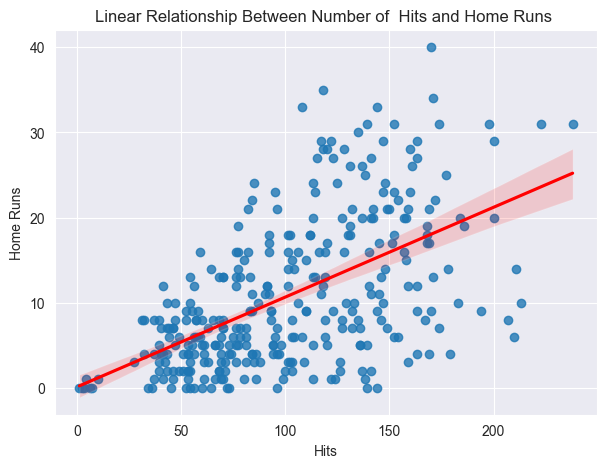

In [240]:
# Scatter Plot with Regression Trend Line for Hitters 
plt.figure(figsize=(7,5))
sns.regplot(x="Hits", y="HmRun", data= Data_Frame_Hitters, line_kws={"color":"red"})
plt.title("Linear Relationship Between Number of  Hits and Home Runs ")
plt.xlabel("Hits")
plt.ylabel("Home Runs")
plt.grid(True)
plt.show()

This scatter plot shows a positive linear relationship between hits and home runs. Despite the spread of the datapoints, they generally form the same shape as the trendline. 

Text(0.5, 1.0, 'KDE Contour Plot of Hits vs Home Runs')

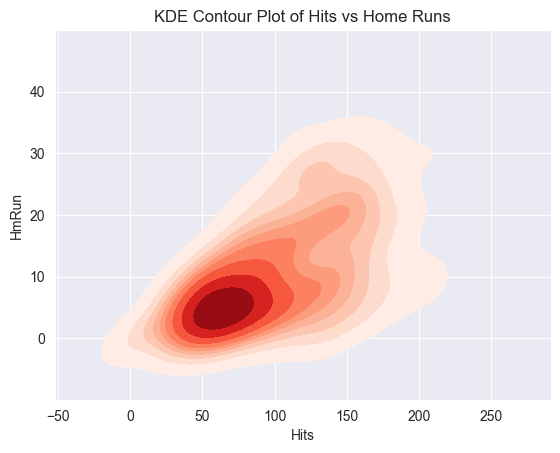

In [241]:
# KDE Contour Plot Visual 
sns.kdeplot(data=Data_Frame_Hitters, x="Hits", y="HmRun", fill=True, cmap="Reds")
plt.title ("KDE Contour Plot of Hits vs Home Runs")


I used the Kernal Density Estimator plot to find where the majority of the observations in this dataset exist on the continuum of home runs vs. hits. The highest density of players hit between roughly 50-75 hits with 1 to 10 homeruns. This mirrors what happens in baseball games, not every hitter is going to get a homerun, but generally there is an upward trend overall trend of more homeruns as the number of hits increases. 

(d) Comment the questions (and answers) in this analysis. Were you able to answer all of these questions? Are all questions well defined? Is the data good enough to answer all these?

I was able to answer my question on whether there was a general pattern of number of home runs vs number of hits. This dataset is good enough to answer this question, but I think that the scatterplot is the easier visual to interpret and tell the story of a relationship. The KDE visual shows where the datapoints are, but does not have the same inferential narrative that scatterplots do. 

### Problem 3

Points: 20

In this problem, we will use data available in [Machine Learning with R by Brett Lantz](https://subscription.packtpub.com/search?query=machine%20learning%20r). This data was available in the public domain and a few version exist online. 

The data describe individual medical costs billed by health insurance. For each observation, there is information about:
- age: age of primary beneficiary of the insurance policy
- sex: the person's sex, measured here a binary gender
- bmi: body mass index, providing an understanding of body, weights that are relatively high or low relative to height, (kg / m ^ 2)
- children: number of children/dependents covered by health insurance
- smoker: smoking status of the primary beneficiary
- region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.
- charges: medical costs billed by health insurance

In our analysis, we will be interested in the relationship between `charges` and the individual characteristics measured. 

In [242]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In our analysis, we will be interested in the relationship between charges and the individual characteristics measured.

(a) Examine the bivariate relationships present in the data. Briefly discuss notable results.

In [243]:
# Categorical Conversion of Insurance 

df['smoker']=df['smoker'].astype('category')
df['sex']=df['sex'].astype('category')
df['region']=df['region'].astype('category')


               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


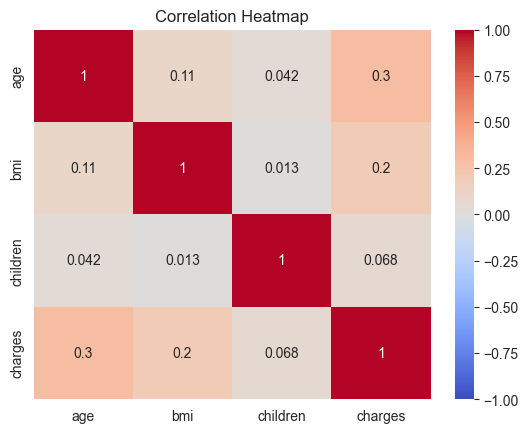

In [244]:
# Correlation calculation plus heatmap 
print(df[['age','bmi','children', 'charges']].corr())

sns.heatmap(df[['age','bmi','children','charges']].corr(),
annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

This correlation heatmap shows relationships between each of the (numeric) variables. All of the coeffients are positive here, even if the strengths of association are not particularly strong. 

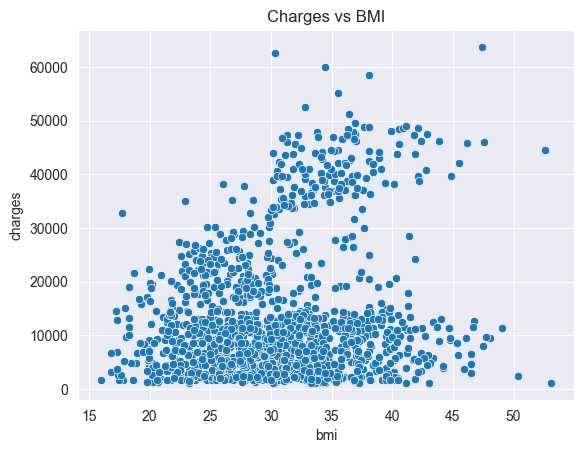

In [245]:
# Scatter plot for Charges vs BMI 
sns.scatterplot(data=df, x='bmi', y='charges')
plt.title("Charges vs BMI")
plt.show()

This scatter plot also shows data points also an upward slope direction, although the degree of linearity ( assuming the relationship between bmi and charges accrued is in fact linear) might vary. 

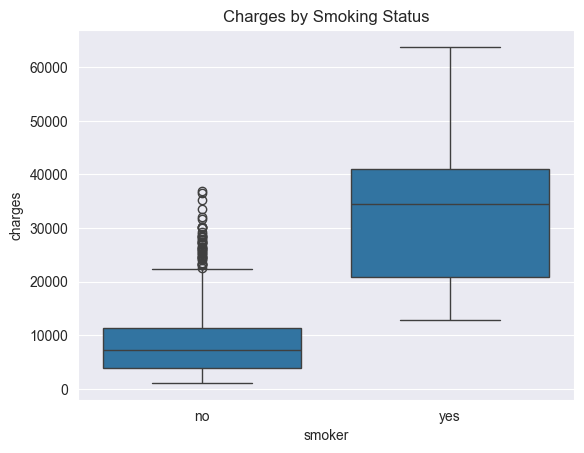

In [246]:
# Category Box Plot 
sns.boxplot(data=df, x='smoker', y='charges')
plt.title ("Charges by Smoking Status")
plt.show()

These box plots were done to show the distribution of outliers for each value for the categorical variable of "smoker." For the non smokers, this is indicated by the presence of points outside of the whiskers. 

(b) Fit a multiple linear regression model. How much variance in the medical costs(charges) does this variable- bmi explain?

In [247]:
df.dtypes # sanity check 

age            int64
sex         category
bmi          float64
children       int64
smoker      category
region      category
charges      float64
dtype: object

In [248]:
# Multi-Linear regression model 
import statsmodels.formula.api as smf

model_insurance = smf.ols (
    "charges ~ bmi + age + children + C(sex) + C(smoker)+ C(region)",
    data=df
).fit()

print(model_insurance.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Sun, 30 Nov 2025   Prob (F-statistic):               0.00
Time:                        22:38:07   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept              -1.19

OLS Documentation Reference: 

Geeks For Geeks (2025, July 23). Interpreting the results of Linear Regression using OLS Summary Retrieved November 25, 2025, from https://www.geeksforgeeks.org/machine-learning/interpreting-the-results-of-linear-regression-using-ols-summary/

In [249]:
#  LinRegression ; partial variance calculation for bmi 

X= df[["bmi"]] # predictor 
Y= df["charges"] # outcome 

X= sm.add_constant(X) # intercept 

model_insurance= sm.OLS(Y,X).fit()

print(model_insurance.summary())





                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     54.71
Date:                Sun, 30 Nov 2025   Prob (F-statistic):           2.46e-13
Time:                        22:38:08   Log-Likelihood:                -14451.
No. Observations:                1338   AIC:                         2.891e+04
Df Residuals:                    1336   BIC:                         2.892e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1192.9372   1664.802      0.717      0.4

BMI has an R<sup>2</sup> of 0.039, which means that it explains 3.9% of the variance for medical costs. 

(c) Evaluate the statistical assumptions in your regression analysis from part (b) by performing a basic analysis of model residuals and any unusual observations. Discuss any concerns you have about your model.

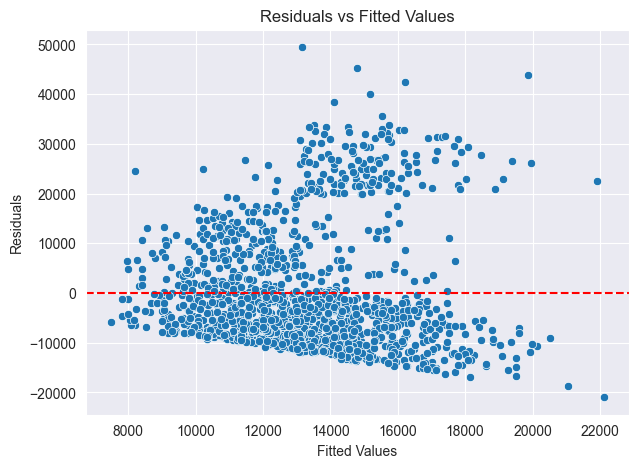

In [250]:
# Residuals analysis # Multiple! 

residuals= model_insurance.resid
fitted= model_insurance.fittedvalues 

plt.figure(figsize=(7,5))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values") 
plt.show()



Interestingly, according to this visual, the relationship appears to be non-linear, as indicated by the spread of the data points around the dashed line.  There is clearly heteroscedascity present( unequal variances). This indicate that the true relationship between covariates and the outcome might not be linear. 

(d) Use a stepwise model selection procedure of your choice to obtain a "best" fit model. Is the model different from the full model you fit in part (b)? If yes, how so?

In [251]:
# Stepwise for Insurance 

df_DUMMY = pd.get_dummies(df, drop_first=True)

y= df_DUMMY["charges"].astype(float)
X= df_DUMMY.drop(columns=["charges"]).astype(float)

def stepwise_selection_insurance (X,y,initial_list=[],threshold_in=0.01,threshold_out=0.05,verbose=True):
    
    if initial_list is None:
        initial_list=[]
    included = list(initial_list)
    
    while True:
            changed = False 

            # Forward 
            excluded= list(set(X.columns)-set(included))
            new_pval = pd.Series(index=excluded, dtype=float)
            for col in excluded: 
                X_model= sm.add_constant(X[included +[col]])
                model_insurance = sm.OLS(y, X_model).fit()
                new_pval[col]=model_insurance.pvalues[col]
            best_pval= new_pval.min() if not new_pval.empty else None 

            if best_pval is not None and best_pval < threshold_in:
                 best_feature= new_pval.idxmin()
                 included.append(best_feature)
                 changed=True
                 if verbose: 
                        print ("Add ", best_feature, "with p=", best_pval)

            # Backward 
            if included: 
                    X_model= sm.add_constant(X[included])
                    model_insurance = sm.OLS(y, X_model).fit()
                    pvalues = model_insurance.pvalues.iloc[1:]
                    worst_pval = pvalues.max()

                    if worst_pval > threshold_out: 
                        worst_feature = pvalues.idxmax()
                        included.remove(worst_feature)
                        changed = True 
                        if verbose: 
                              print("Drop", worst_feature, "with p", worst_pval)

            if not changed: 
                  break 
    return included



### Stepwise Documentation Reference: 

Geeks For Geeks (2025, July 23). Stepwise Regression in Python. Retrieved November 25, 2025, from https://www.geeksforgeeks.org/machine-learning/stepwise-regression-in-python/

In [252]:
# Time to run stepwise 

best_features= stepwise_selection_insurance (X,y)
print("\nBest model features:")
print(best_features)

Add  smoker_yes with p= 8.271435842176277e-283
Add  age with p= 2.90975066738233e-92
Add  bmi with p= 2.4185578494723593e-30
Add  children with p= 0.0006077158346795007

Best model features:
['smoker_yes', 'age', 'bmi', 'children']


The best fit model here included other variables besides bmi, such as children, age, and whether or not an individual was a smoker. These relationships between the predictor outcome variable of charges was found to be statisically significant with all p-values less than 0.05. 

EXTRA CREDIT (Max point: 2) : Fit a regression tree using the same covariates in your "best" fit model from part (d). Use cross validation to select the "best" tree. Compare the models from part (d) and (f) based on their performance. Which do you prefer? Be sure to justify your preference.

In [253]:
# Import ML Libraries ; 

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

best_features = ['smoker_yes', 'age', 'bmi', 'children'] # from the stepwise 

X_best = X[best_features]
y_best = y 

# split into Training and Testing 

X_train, X_test, y_train, y_test = train_test_split(
    X_best,y_best, test_size=0.2, random_state=42
)

In [254]:
# Cross Validation to find the best tree with the best number of leaf nodes # Multiple 

leaf_range = range(2,21)
cv_scores = []

for leaves in leaf_range: 
        tree = DecisionTreeRegressor(max_leaf_nodes=leaves, random_state= 42)
        mse = -cross_val_score( tree, X_train, y_train,
                               cv=10,
                               scoring="neg_mean_squared_error").mean()
        cv_scores.append(mse)

best_leaf_nodes = leaf_range[np.argmin(cv_scores)]
print("Best number of leaf nodes:", best_leaf_nodes)



Best number of leaf nodes: 13


In [255]:
# Find the best tree 

best_tree= DecisionTreeRegressor(
    max_leaf_nodes= best_leaf_nodes,
    random_state=42
)

best_tree.fit(X_train, y_train)

y_pred_tree = best_tree.predict(X_test)
tree_mse = mean_squared_error(y_test, y_pred_tree)
tree_rmse = np.sqrt(tree_mse)

print ("Regression Tree RMSE:", tree_rmse)


Regression Tree RMSE: 5030.121276978387


In [256]:
# Comparison to Stepwise Regression 

X_train_reg = sm.add_constant(X_train)
X_test_reg = sm.add_constant(X_test)

reg_model = sm.OLS(y_train, X_train_reg).fit()
y_pred_reg = reg_model.predict(X_test_reg)

reg_rmse = np.sqrt(mean_squared_error(y_test,y_pred_reg))
print ("Stepwise Regression RMSE:", reg_rmse)

Stepwise Regression RMSE: 5829.378521780664


The decision tree has the lower root means square error (RMSE); thus it is a better fit model compared to the stepwise regression model. 

RMSE is metric that tells us the average distance between the predicted values from the model and the actual values in the dataset. The lower the RMSE, the better a given model is able to “fit” a dataset. <sup>1</sup>

Reference: 

1. Zach Bobbitt. (2021, May 10). How to Interpret Root Mean Square Error (RMSE). Statology. https://www.statology.org/how-to-interpret-rmse/. 

### Decision Tree Documentation Reference: 

Geeks For Geeks (2024, May 14). Python | Decision Tree Implementation. Retrieved November 25, 2025, from https://www.geeksforgeeks.org/machine-learning/decision-tree-implementation-python/

### Problem 4

Points: 20

The Wisconsin Breast Cancer dataset is available on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original). Our goal in this problem will be to predict whether observations (i.e. tumors) are malignant or benign. We will use the original dataset in this problem. 

(a) Obtain the data and load it into your programming environment by pulling it directly from the web (links provided below). (Do **not** download it and import it from a CSV file.) Give a brief description of the data. 

In [257]:
# Web location of data file
location = "http://archive.ics.uci.edu/ml/machine-learning-databases/"
dataframe = "breast-cancer-wisconsin/breast-cancer-wisconsin.data"

In [258]:
# imported from UC Irvine Repo 
# Wolberg, W. (1990). Breast Cancer Wisconsin (Original) [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5HP4Z.

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_original = fetch_ucirepo(id=15) 
  
# data (as pandas dataframes) 
features = breast_cancer_wisconsin_original.data.features # X 
targets = breast_cancer_wisconsin_original.data.targets # Y 
  
# metadata 
print(breast_cancer_wisconsin_original.metadata) 
  
# variable information 
print(breast_cancer_wisconsin_original.variables) 



{'uci_id': 15, 'name': 'Breast Cancer Wisconsin (Original)', 'repository_url': 'https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original', 'data_url': 'https://archive.ics.uci.edu/static/public/15/data.csv', 'abstract': 'Original Wisconsin Breast Cancer Database', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 699, 'num_features': 9, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['Class'], 'index_col': ['Sample_code_number'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1990, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C5HP4Z', 'creators': ['WIlliam Wolberg'], 'intro_paper': None, 'additional_info': {'summary': "Samples arrive periodically as Dr. Wolberg reports his clinical cases. The database therefore reflects this chronological grouping of the data. This grouping information appears immediately below, having been removed fro

(b) Investigate the data, ensuring that each variable is properly named and cast as the correct data type. Discuss any missing data.

In [259]:
# Data Inspection 

# features 
features.info() # X

# targets 
targets.info() # Y 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Clump_thickness              699 non-null    int64  
 1   Uniformity_of_cell_size      699 non-null    int64  
 2   Uniformity_of_cell_shape     699 non-null    int64  
 3   Marginal_adhesion            699 non-null    int64  
 4   Single_epithelial_cell_size  699 non-null    int64  
 5   Bare_nuclei                  683 non-null    float64
 6   Bland_chromatin              699 non-null    int64  
 7   Normal_nucleoli              699 non-null    int64  
 8   Mitoses                      699 non-null    int64  
dtypes: float64(1), int64(8)
memory usage: 49.3 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Class   699 non-null    int6

In [260]:
# concatonation of features and targets to prepare for training and testing partition 

concat_feat_targ= pd.concat([targets,features],axis=1) 
concat_feat_targ.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Class                        699 non-null    int64  
 1   Clump_thickness              699 non-null    int64  
 2   Uniformity_of_cell_size      699 non-null    int64  
 3   Uniformity_of_cell_shape     699 non-null    int64  
 4   Marginal_adhesion            699 non-null    int64  
 5   Single_epithelial_cell_size  699 non-null    int64  
 6   Bare_nuclei                  683 non-null    float64
 7   Bland_chromatin              699 non-null    int64  
 8   Normal_nucleoli              699 non-null    int64  
 9   Mitoses                      699 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 54.7 KB


In [261]:
concat_feat_targ.isna().sum() # check for missing values first 

Class                           0
Clump_thickness                 0
Uniformity_of_cell_size         0
Uniformity_of_cell_shape        0
Marginal_adhesion               0
Single_epithelial_cell_size     0
Bare_nuclei                    16
Bland_chromatin                 0
Normal_nucleoli                 0
Mitoses                         0
dtype: int64

In [262]:
features.isna().sum()

Clump_thickness                 0
Uniformity_of_cell_size         0
Uniformity_of_cell_shape        0
Marginal_adhesion               0
Single_epithelial_cell_size     0
Bare_nuclei                    16
Bland_chromatin                 0
Normal_nucleoli                 0
Mitoses                         0
dtype: int64

The only column here with missing data is "Bare_nuclei." 

In [263]:
concat_feat_targ.head()

,Class,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses
0,2,5,1,1,1,2,1.0,3,1,1
1,2,5,4,4,5,7,10.0,3,2,1
2,2,3,1,1,1,2,2.0,3,1,1
3,2,6,8,8,1,3,4.0,3,7,1
4,2,4,1,1,3,2,1.0,3,1,1


In [264]:
# Remove rows with Missing Values, in this case Bare_Nuclei 

clean_data = concat_feat_targ.dropna(subset=['Bare_nuclei'])




In [265]:
clean_data.isna().sum() # quick check of sanity 

Class                          0
Clump_thickness                0
Uniformity_of_cell_size        0
Uniformity_of_cell_shape       0
Marginal_adhesion              0
Single_epithelial_cell_size    0
Bare_nuclei                    0
Bland_chromatin                0
Normal_nucleoli                0
Mitoses                        0
dtype: int64

(c) Split the data into a training and test set such that a random 70\% of the observations are in the training set.

In [266]:
# split training and test data 

from sklearn.model_selection import train_test_split

#DatX= features # X 
DatX = clean_data



#DatY= targets # Y 
DatY= clean_data['Class']


DatX_train, DatX_test, DatY_train, DatY_test = train_test_split(
    DatX, DatY, test_size=0.30, random_state=123, stratify=DatY
)





(d) Fit a ML model to predict whether tissue samples are malignant or benign. Then use your model to classify cases in your test set, which is the remaining 30% of the all the observations. Compute and discuss the resulting confusion matrix. Be sure to address which of the errors that are identified you consider most problematic in this context.

In [267]:
# Fitting the model 

log_model_ML= LogisticRegression(max_iter=500)
log_model_ML.fit (DatX_train, DatY_train.values.ravel());

/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: over

In [268]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = log_model_ML.predict(DatX_test)

confused = confusion_matrix(DatY_test,y_pred)
print(confused)

print( classification_report(DatY_test,y_pred))


[[132   1]
 [  0  72]]
              precision    recall  f1-score   support

           2       1.00      0.99      1.00       133
           4       0.99      1.00      0.99        72

    accuracy                           1.00       205
   macro avg       0.99      1.00      0.99       205
weighted avg       1.00      1.00      1.00       205



/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


According to the Repo Documentation, the class labels of 2 and 4 represent benign and malignant classes, respectively. 

Wolberg, W. (1990). Breast Cancer Wisconsin (Original) [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5HP4Z.

Note: This ML model and the confusion matrix were constructed after I removed the missing values from the "Bare Nuclei" column. 

This confusion matrix correctly identified 132 true positive benign vs true negative malignant, with only one false positive. The benign class had a precision and recall of 100% and 99%, respectively; the malignant class has a precision and recall of 99% and 100%. Finfally, to provide a better sense of the model's overall performance the F1-score combines precision and recall into a single metric to balance their trade-off. <sup>1</sup>

Reference: 

GeeksforGeeks. (2017, October 15). Understanding the Confusion Matrix in Machine Learning. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/

### Problem 5

Points: 10

Please answer the questions below by writing a short response. 

(a) Describe three real-life applications in which **classification** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

### Three real life applications where classification may be useful 

1. Medical diagnoses. One example is hypertension. The predictors might be covariates such as systolic and diastolic blood pressure readings, weight, A1C(blood sugar levels), BMI, triglyceride counts, etc.  all of which could possibly predipose someone to a response variable outcome such as the presence of absence of hypertension. This would be prediction due to the measured predictor coveriates to estimate a binary outcome response variable( Montagna et al., 2022). 

2. Spam/ Phishing filtering in email. This is a real life example which takes into account predictor information such as subject line keywords, email content( words and images), the email address of sender( which may not always be legitamate of course), or presence or absence of attached files. The outcome variable is whether or not the email is spam and or phishing and it is flagged accordingly.  This is predictive in nature because of this binary outcome in which an email can be flagged as spam or not ( Bergholz et al., 2008). 

3. Bank/Credit Card Fraud Detection and Prevention. This is a semi-supervised method of classification similar  medical diagnoses and spam/phishing filters,  although for this situation the predictors would be transaction history, time stamps of purchases, frequency of purchases, and the outcome variable would be which banks label transations as either binary outcome fraduent or legitimate(Bahnsen et al., 2016)

All of these situations are predictive because classification doesn't explain why or how covariates influence eachother, rather, classification aims to identify and classify data as belonging to one class or another.  "hypertensive" vs "normal",  "spam" vs " not spam" , " phishing" vs "not phishing", and "fraudulent transaction" vs "legitamate transation."  

References: 

1. Montagna, S., Pengo, M. F., Ferretti, S., Borghi, C., Ferri, C., Grassi, G., Muiesan, M. L., & Parati, G. (2022). Machine Learning in Hypertension Detection: A Study on World Hypertension Day Data. Journal of medical systems, 47(1), 1. https://doi.org/10.1007/s10916-022-01900-5
2. Bergholz, A., Chang, J.H., Paass, G., Reichartz, F., & Strobel, S. (2008). Improved Phishing Detection using Model-Based Features. International Conference on Email and Anti-Spam.
3. Bahnsen, A. C., Aouada, D., Stojanovic, A., & Ottersten, B. (2016). Feature engineering strategies for credit card fraud detection. Expert Systems with Applications, 51, 134–142. https://doi.org/10.1016/j.eswa.2015.12.030

b) Describe three real-life applications in which **regression** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

### ( work on this one )

### Three real life applications where regression may be useful 

1. Measuring Global Climate Change, in particular Increase in Global Temperature with Respect to Time( in years) would be a good example of a regression, because both temperature are continuous variables. Possible predictors include atmospheric CO2 levels in ppm ( and other atmospheric gases too), solar radiation, time of year(equinox or solsttice)sea level measurements,  human land use activity ( urbanization, deforestation, zoning),  presence or absence of El Nino or La Nina patterns, The outcome would be the global average temperature reading(in Celsius) per year ( Hegerl et al., 2007). 

2. Measuring Obesity Rates in a Population. Possible predictors can be  demographic (age, educational attainment,  behavioral(exercise levels and quantity)and societal ( neighborhood walkability ratings, presence of healthy grocery stores in neighborhoods, presence or absence of parks and or fitness facilities). The outcome would be the obesity rate in percentage of a population (Amarasinghe et al., 2009). 

3. Measuring Rising Costs of Groceries. Predictors could be number of items purchased, frequency of visits to the grocery store, location of grocery store( urban, suburban, rural) household size,  vendor costs, branding( generic vs store vs vendor), manufacturing costs, shipping costs, supply chains networks,  tax rates, inflation rate,  The outcome is the total household bill for groceries (  Codjia et al., 2022)


Depending on the research question, regression can be either predictive or inferential in any of these three specific situations because of the forecasting nature of predictive analyses and modeling and inferential for wanting to understand the strength of any extant relationships between covariates and an outcome( or relationships between covariates and how they independently or intersectionally influence the outcome). 

References: 

1. Hegerl, G.C., F. W. Zwiers, P. Braconnot, N.P. Gillett, Y. Luo, J.A. Marengo Orsini, N. Nicholls, J.E. Penner and P.A. Stott, 2007: Understanding and Attributing Climate Change. In: Climate Change 2007: The Physical Science Basis. Contribution of Working Group I to the
Fourth Assessment Report of the Intergovernmental Panel on Climate Change [Solomon, S., D. Qin, M. Manning, Z. Chen, M. Marquis,
K.B. Averyt, M. Tignor and H.L. Miller (eds.)]. Cambridge University Press, Cambridge, United Kingdom and New York, NY, USA

2. Amarasinghe, A., D’Souza, G., Brown, C., Oh, H., & Borisova, T. (2009). The Influence of Socioeconomic and Environmental Determinants on Health and Obesity: A West Virginia Case Study. International Journal of Environmental Research and Public Health, 6(8), 2271-2287. https://doi.org/10.3390/ijerph6082271

3. Codjia, C. O., & Saghaian, S. H. (2022). Determinants of Food Expenditure Patterns: Evidence from U.S. Consumers in the Context of the COVID-19 Price Shocks. Sustainability, 14(13), 8156. https://doi.org/10.3390/su14138156

(c) What are the advantages and disadvantages of a very flexible (versus a less flexible) approach for regression or classification? Under what circumstances might a more flexible approach be preferred to a less flexible approach? When might a less flexible approach be preferred?



A more flexible apporach might be preferred when performing non-parametric regression and or classifications. For example, one of the best documented non-parametric methods is  K-nearest neighbors(KNN); in sumation KNN regression first identifies the 'K' training observations that are closest to
x0, represented by N0, which then estimates f(x0) using the average of all the training responses in N0. ( James et al., 2023).KNN can capture non-linear patterns and relationships for the model function f(x0), provided there are enough neighbors (large K). Caveats to this are mostly in cases which there are not enough neighbors(K) which can potentially lead to overfitting. Too many neighbors can lead to the bias-variance trade off demonstrated in KNN to be tipped too far into the bias direction, leading to masking of the true relationship between predictors and outcome. 

A less flexible approach might be preferred, when inference is the goal, for instance the linear regression model may be a good choice since it will be quite easy to understand
the relationship between outcome  Y and predictors  X1,X2, . . . ,Xp( James et al., 2023). However, if the true relationship between predictors and outcome is NOT linear, a linear model might not be the best fit. 


Reference: 

1. Gareth, J., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). An introduction to statistical learning: With applications in python.

### Problem 6

Points: 10

Suppose we have a dataset with five predictors, $X_1 =$ GPA, $X_2 =$ IQ, $X_3 =$ Gender (1 for Female, and 0 for Male), $X_4 =$ Interaction between GPA and IQ, and $X_5 =$ Interaction between GPA and Gender. Note: the data here is limited as gender was collected as a binary variable.

The response is starting salary after graduation (in thousands of dollars). Suppose we use least squares to fit the model and get $\hat{\beta}_0=50, \hat{\beta}_1=20, \hat{\beta}_2=0.07, \hat{\beta}_3=35, \hat{\beta}_4=0.01$, and $\hat{\beta}_5=-10$. 

(a) Which answer is correct and why? <font color = red>[single choice question]

i. For a fixed value of IQ and GPA, males earn more on average than females.

ii. For a fixed value of IQ and GPA, females earn more on average than males.

iii. For a fixed value of IQ and GPA, males earn more on average than females provided that the GPA is high enough.

iv. For a fixed value of IQ and GPA, females earn more on average than males provided that the GPA is high enough.

### Answer to Question 6 (a)

III. For a fixed value of IQ and GPA, males earn more on average than females, provided that the GPA is high enough. 

The formula: 

$\hat{\beta}_0=50, \hat{\beta}_1=20(GPA), \hat{\beta}_2=0.07(IQ), \hat{\beta}_3=35(Gender), \hat{\beta}_4=0.01$,(GPAxIQ) and $\hat{\beta}_5=-10$(GPAxGender). 

Coefficients: 

Males= 50+20+0.07+0.01 

Females= 50+20+0.07+35+0.01-10; on account of Gender =1 for female 

Difference between Female and Male: 

Females-Males= 35-10 

This means  is when the values for IQ and GPA are fixed at a high GPA, males earn more on average than females, thus demonstating the effect of the intersection between GPA and gender on salary. 



(b) Write down the least square function and then predict the salary of a female with IQ of 110 and a GPA of 4.0.

Predicted Salary of a female with 110 IQ and GPA of 4.0 ( n thousands of dollars )

=50+ 20(4)[GPA] + 0.07(110)[IQ] + 35(1)[Gender] + 0.01(440)[GPAxIQ]-10(4)(1)[GPAxGender] 

=50+80 + 7.7+ 35+ 4.4-40 = 137.1 or $137,100 salary 

(c) True or false: Since the coefficient for the GPA/IQ interaction term is very small, there is little evidence of an interaction effect. Justify your answer.

This is False! 
A  small coefficient for an interaction term is NOT indicative of a negligle interaction effect. 
A small coefficient is not sufficient evidence of any interaction effect present. In this case, we simply do not have enough information, namely the p-value to make this type of assertion. 

 A paper published by Jabbari et al., further bolsters this argument. They state that if a researcher is interested in testing for  interaction, then the researcher needs to determine the smallest meaningful interaction effect (i.e. the smallest difference in slopes that would be meaningful for a one unit change in the predictor, recalling that the variables are standardized so a one unit change is a one standard deviation change; this he decision is highly subjective and dependent on the context of the research, we can use general guidelines as a starting point( Jabbari et al., 2021). 

 Reference: 

 1. Jabbari, Y., & Cribbie, R. (2021). Negligible interaction test for continuous predictors. Journal of applied statistics, 49(8), 2001–2015. https://doi.org/10.1080/02664763.2021.1887102

### Problem 7 - Extra Credit

Points: Max. 4

Suppose that $X_1, \ldots X_n$ form a random sample from a Poisson distribution for which the mean $\theta$ is unknown, $(\theta>0)$.

(a) Determine the MLE of $\theta$, assuming that at least one of the observed values is different from 0. Show your work.

(b) Show that the MLE of $\theta$ does not exists if every observed value is 0.

### Problem 8 - Extra Credit

Points: Max. 4

In this extra credit problem, you'll build a simple web scraper to collect and process text data. You'll write the code necessary to scrape lyrics for a desired artist. Your code should be structured such that one can easily execute your scraping functions for a given artist. There are three deliverables for this assignment:

1. A set of functions necessary for scraping the lyrics of a specific artist.
2. An example implementation of using your functions.
3. A file of example output from your notebook implementation.

The specific approach that you take to structuring your code is up to you, but the final output .csv data should have the following columns (each row is a song from an artist that you choose):

- Column 1: artist
- Column 2: album
- Column 3: song title
- Column 4: URL of song lyrics
- Column 5: song lyrics (all of the lyrics in one column)
- Column 6: number of words in the song

**Data Scraping:** The actual scraping of data should be supported by separate functions that accomplish these tasks:

1. Given an artist, identify all of their albums, songs, and links to songs.
2. Given a set of song links (from step 1), collect the lyrics to each song and store them in a data frame.

In order to do this, you'll need to understand the structure of your lyrics site. The site you use is up to you, but all of this information should be available on lyrics.com.

**Data Processing:**

Once you've scraped the data, you'll need to do some simple text analysis to generate your columns of interest (feel free to do this as part of step 2 above, the collection of lyrics for each song or as a separate step entirely). Recall you are aiming to count the number of words in each song.

**Example Implementation:**

You should demonstrate the implementation of your data scraping functions with a particular artist. To do this you can simply set an artist, and run your scraping functions. The way in which you choose to structure your functions is up to you, as long as the implementation and documentation is clear. One way in which we'll test this is changing the artist to confirm the flexibility of your implementation. 

It may look something like this:

In [269]:
def get_songs(a):
    return a
def get_all_lyrics(s):
    return s
def save_lyrics(l):
    return l

In [270]:
# NOTE THIS CODE WILL NOT RUN 
# UNTIL YOU WRITE YOUR WEB SCRAPING FUNCTIONS

# Get songs
artist = 'Adele'
all_songs = get_songs(artist) 

# Get lyrics -- internally, you may want to another function in your library, such as get_lyrics()
lyrics = get_all_lyrics(all_songs)

# Save data -- this function should identify the name of the artist and use it in the .csv file it saves
save_lyrics(lyrics)

'Adele'

(a) Write a function to get all the songs of a particular artist. 

(b) Write a function to get all the lyrics for a particular song. You may also want to write a function to get all the lyrics for a list of songs.  

(c) Choose a particular artist. Get all their songs. Get all the lyrics for their songs. Process the data so that you end up with a nice, tidy data structure as described in the instructions (i.e. the six columns listed above). Write out the data to a CSV file.  

(d) Produce one visualization of the data to aids in understanding the distribution of words in songs for a particular artist. Comment on what you find.  